# Notebook 1: Data Exploration & Preprocessing
**Project:** Movie/Content Review Summarizer  
**Dataset:** IMDb 50K Movie Reviews  
**Techniques:** NLP · Text Preprocessing · Word Embeddings (Word2Vec, GloVe)

---

## 1.1 Install & Import Libraries

In [13]:
# Install required libraries (run once)
# !pip install pandas numpy matplotlib seaborn nltk wordcloud gensim scikit-learn transformers torch datasets

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

from collections import Counter
from sklearn.model_selection import train_test_split

# Download NLTK resources
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

print('✅ All libraries loaded successfully')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Chanidu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Chanidu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Chanidu\AppData\Roaming\nltk_data...


✅ All libraries loaded successfully


[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Chanidu\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Chanidu\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


## 1.2 Load the Dataset

In [14]:
# Load the IMDb dataset
# Make sure IMDB_Dataset.csv is in the same folder or update the path
df = pd.read_csv('../data/IMDB_Dataset.csv')

print('Dataset shape:', df.shape)
print('\nColumn names:', df.columns.tolist())
print('\nFirst 3 rows:')
df.head(3)

Dataset shape: (50000, 2)

Column names: ['review', 'sentiment']

First 3 rows:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


## 1.3 Data Exploration (EDA)

In [15]:
# Check for null values and basic info
print('=== Dataset Info ===')
print(df.info())
print('\n=== Null Values ===')
print(df.isnull().sum())
print('\n=== Sentiment Distribution ===')
print(df['sentiment'].value_counts())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None

=== Null Values ===
review       0
sentiment    0
dtype: int64

=== Sentiment Distribution ===
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


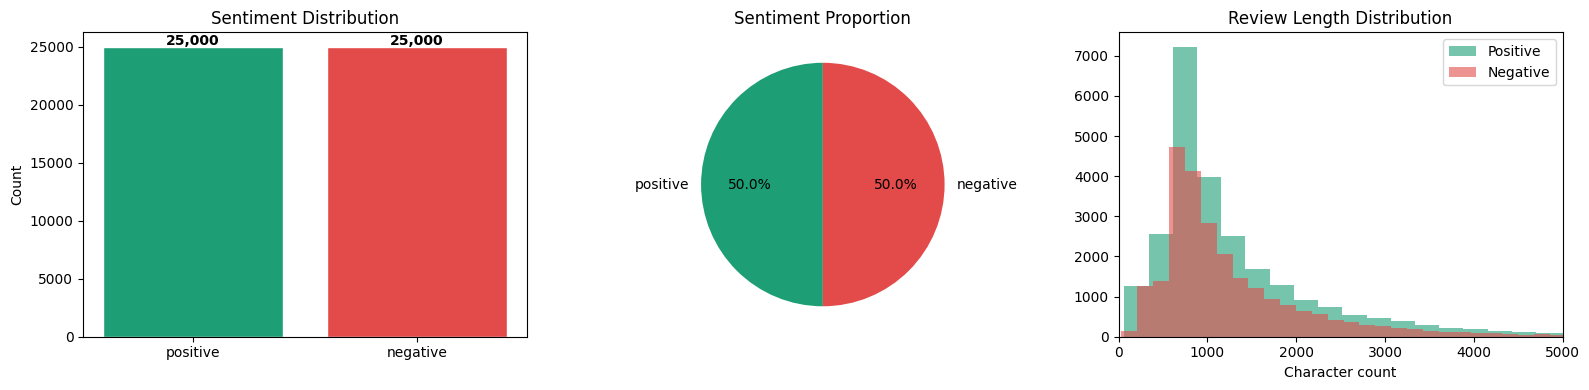

📊 EDA chart saved to outputs/


In [16]:
# Plot sentiment distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Bar chart
counts = df['sentiment'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#1D9E75', '#E24B4A'], edgecolor='white')
axes[0].set_title('Sentiment Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#1D9E75', '#E24B4A'], startangle=90)
axes[1].set_title('Sentiment Proportion')

# Review length distribution
df['review_length'] = df['review'].apply(len)
axes[2].hist(df[df['sentiment']=='positive']['review_length'], bins=50,
             alpha=0.6, color='#1D9E75', label='Positive')
axes[2].hist(df[df['sentiment']=='negative']['review_length'], bins=50,
             alpha=0.6, color='#E24B4A', label='Negative')
axes[2].set_title('Review Length Distribution')
axes[2].set_xlabel('Character count')
axes[2].legend()
axes[2].set_xlim(0, 5000)

plt.tight_layout()
plt.savefig('../outputs/01_eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 EDA chart saved to outputs/')

In [17]:
# Word count statistics
df['word_count'] = df['review'].apply(lambda x: len(str(x).split()))

print('=== Review Statistics ===')
print(df.groupby('sentiment')['word_count'].describe().round(1))

=== Review Statistics ===
             count   mean    std   min    25%    50%    75%     max
sentiment                                                          
negative   25000.0  229.5  164.9   4.0  128.0  174.0  278.0  1522.0
positive   25000.0  232.8  177.5  10.0  125.0  172.0  284.0  2470.0


## 1.4 NLP Text Preprocessing Pipeline

In [18]:
# Define the full NLP preprocessing pipeline
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Full NLP preprocessing pipeline:
    1. Remove HTML tags (e.g. <br />)
    2. Lowercase
    3. Remove punctuation and special characters
    4. Tokenize
    5. Remove stopwords
    6. Lemmatize
    """
    # Step 1: Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    
    # Step 2: Lowercase
    text = text.lower()
    
    # Step 3: Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Step 4: Tokenize
    tokens = word_tokenize(text)
    
    # Step 5: Remove stopwords (keep negation words!)
    negation_words = {'not', 'no', 'nor', 'never', 'neither', "n't"}
    tokens = [t for t in tokens if t not in stop_words or t in negation_words]
    
    # Step 6: Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    
    return ' '.join(tokens)

# Demo on one review
sample = df['review'].iloc[0]
print('ORIGINAL:')
print(sample[:300])
print('\nCLEANED:')
print(preprocess_text(sample)[:300])

ORIGINAL:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru

CLEANED:
one reviewer mentioned watching oz episode youll hooked right exactly happened first thing struck oz brutality unflinching scene violence set right word go trust not show faint hearted timid show pull no punch regard drug sex violence hardcore classic use word called oz nickname given oswald maximum


In [19]:
# Apply preprocessing to the full dataset
print('Preprocessing 50,000 reviews... (may take 2-3 minutes)')
df['cleaned_review'] = df['review'].apply(preprocess_text)

# Encode label: positive=1, negative=0
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print(f'✅ Done! Sample cleaned review:')
print(df['cleaned_review'].iloc[0][:200])
df[['review', 'cleaned_review', 'sentiment', 'label']].head(3)

Preprocessing 50,000 reviews... (may take 2-3 minutes)
✅ Done! Sample cleaned review:
one reviewer mentioned watching oz episode youll hooked right exactly happened first thing struck oz brutality unflinching scene violence set right word go trust not show faint hearted timid show pull


,review,cleaned_review,sentiment,label
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode you...,positive,1
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...,positive,1
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...,positive,1


## 1.5 Word Cloud Visualization

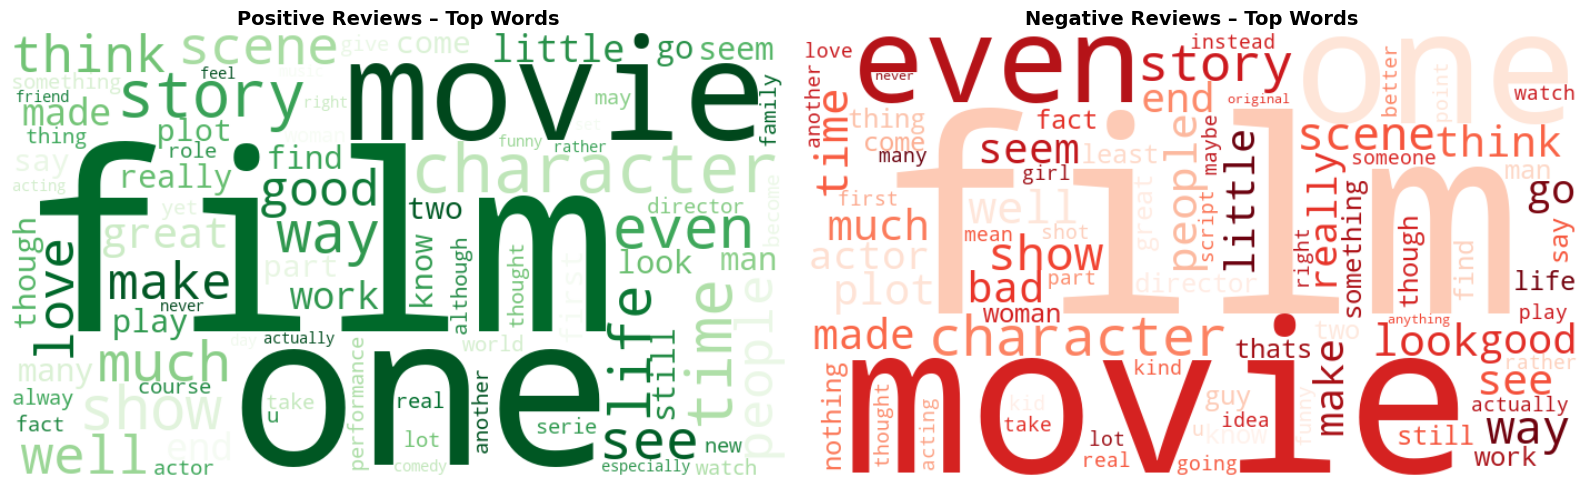

☁️  Word clouds saved to outputs/


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, sentiment, color in zip(axes, ['positive', 'negative'], ['#1D9E75', '#E24B4A']):
    text = ' '.join(df[df['sentiment'] == sentiment]['cleaned_review'])
    wc = WordCloud(width=700, height=400, background_color='white',
                   colormap='Greens' if sentiment == 'positive' else 'Reds',
                   max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{sentiment.capitalize()} Reviews – Top Words', fontsize=14, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('../outputs/02_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print('☁️  Word clouds saved to outputs/')

## 1.6 Word Embeddings – Word2Vec

In [22]:
from gensim.models import Word2Vec
from sklearn.manifold import TSNE

# Prepare tokenized sentences for Word2Vec
sentences = [review.split() for review in df['cleaned_review']]

# Train Word2Vec model
print('Training Word2Vec embeddings...')
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,   # embedding dimension
    window=5,          # context window
    min_count=5,       # ignore words that appear less than 5 times
    workers=4,
    epochs=10
)

w2v_model.save('../models/word2vec_imdb.model')
print(f'✅ Word2Vec trained! Vocabulary size: {len(w2v_model.wv):,}')

# Show similar words
print('\nWords similar to "excellent":')
for word, score in w2v_model.wv.most_similar('excellent', topn=5):
    print(f'  {word}: {score:.3f}')

print('\nWords similar to "terrible":')
for word, score in w2v_model.wv.most_similar('terrible', topn=5):
    print(f'  {word}: {score:.3f}')

Training Word2Vec embeddings...
✅ Word2Vec trained! Vocabulary size: 37,315

Words similar to "excellent":
  superb: 0.881
  terrific: 0.869
  outstanding: 0.844
  fantastic: 0.820
  wonderful: 0.787

Words similar to "terrible":
  horrible: 0.911
  awful: 0.866
  horrendous: 0.830
  atrocious: 0.807
  horrid: 0.783


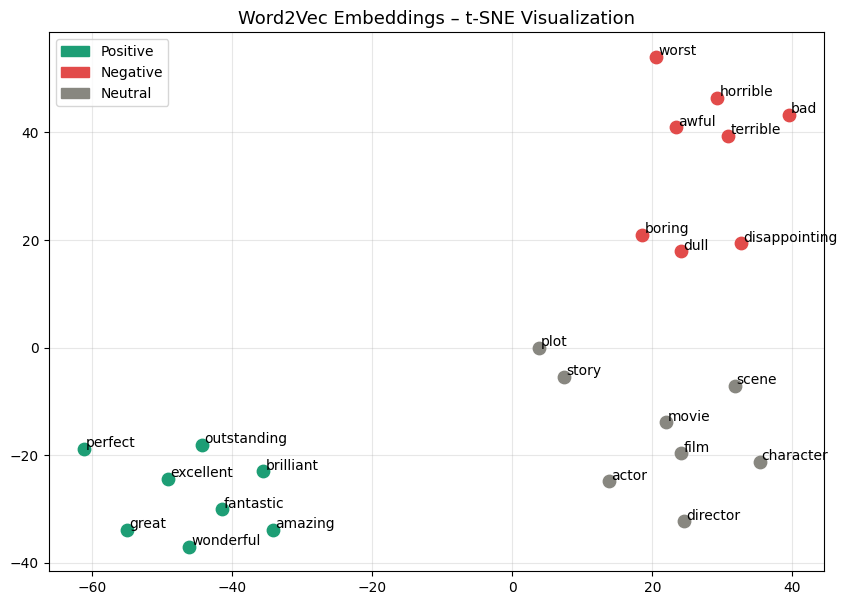

📍 t-SNE plot saved to outputs/


In [23]:
# Visualize Word2Vec embeddings with t-SNE
positive_words = ['excellent', 'brilliant', 'amazing', 'wonderful', 'outstanding', 'fantastic', 'great', 'perfect']
negative_words = ['terrible', 'awful', 'horrible', 'boring', 'disappointing', 'worst', 'bad', 'dull']
neutral_words  = ['movie', 'film', 'story', 'character', 'scene', 'actor', 'director', 'plot']

all_words = positive_words + negative_words + neutral_words
valid_words = [w for w in all_words if w in w2v_model.wv]
vectors = np.array([w2v_model.wv[w] for w in valid_words])

tsne = TSNE(n_components=2, random_state=42, perplexity=5)
coords = tsne.fit_transform(vectors)

plt.figure(figsize=(10, 7))
colors = ['#1D9E75'] * len(positive_words) + ['#E24B4A'] * len(negative_words) + ['#888780'] * len(neutral_words)
for i, word in enumerate(valid_words):
    plt.scatter(coords[i, 0], coords[i, 1], color=colors[i], s=80, zorder=3)
    plt.annotate(word, (coords[i, 0]+0.3, coords[i, 1]+0.3), fontsize=10)

from matplotlib.patches import Patch
legend = [Patch(color='#1D9E75', label='Positive'), Patch(color='#E24B4A', label='Negative'), Patch(color='#888780', label='Neutral')]
plt.legend(handles=legend)
plt.title('Word2Vec Embeddings – t-SNE Visualization', fontsize=13)
plt.grid(True, alpha=0.3)
plt.savefig('../outputs/03_word2vec_tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print('📍 t-SNE plot saved to outputs/')

## 1.7 Train/Validation/Test Split & Save

In [24]:
# Split: 70% train, 15% validation, 15% test
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42, stratify=df['label'])
val_df, test_df   = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['label'])

print(f'Train size:      {len(train_df):,} ({len(train_df)/len(df)*100:.0f}%)')
print(f'Validation size: {len(val_df):,} ({len(val_df)/len(df)*100:.0f}%)')
print(f'Test size:       {len(test_df):,} ({len(test_df)/len(df)*100:.0f}%)')

# Save preprocessed splits
train_df.to_csv('../data/train.csv', index=False)
val_df.to_csv('../data/val.csv', index=False)
test_df.to_csv('../data/test.csv', index=False)
print('\n✅ Preprocessed splits saved to data/')

Train size:      35,000 (70%)
Validation size: 7,500 (15%)
Test size:       7,500 (15%)

✅ Preprocessed splits saved to data/
